In [ ]:
# ============================================================
# Konfiguration (zentral & leicht anpassbar)
# Alle Stellschrauben an einem Ort -> kein Suchen mehr quer durch den Code.
# ============================================================

# Reproduzierbarkeit
SEED = 42

# Pfade
DATA_PATH     = 'Datasets/apple_quality.csv'
MODEL_PATH    = 'Models/iris_net_NextStep5.pth'
ENCODER_PATH  = 'Models/label_encoder_NextStep5.pkl'
SCALER_PATH   = 'Models/scaler_NextStep5.pkl'
METADATA_PATH = 'Models/metadata_NextStep5.json'

# Architektur (die Groesse der versteckten Schicht ist die eigentliche Stellschraube)
HIDDEN_DIM = 5     # Anzahl Neuronen in der versteckten Schicht

# Training
BATCH_SIZE    = 100
LEARNING_RATE = 0.1
MAX_EPOCHS    = 500
PATIENCE      = 100     # Epochen ohne Verbesserung bis zum Early-Stopping-Abbruch

# Scaler-Auswahl: 'standard' | 'minmax' | 'robust'
SCALER_TYPE = 'standard'


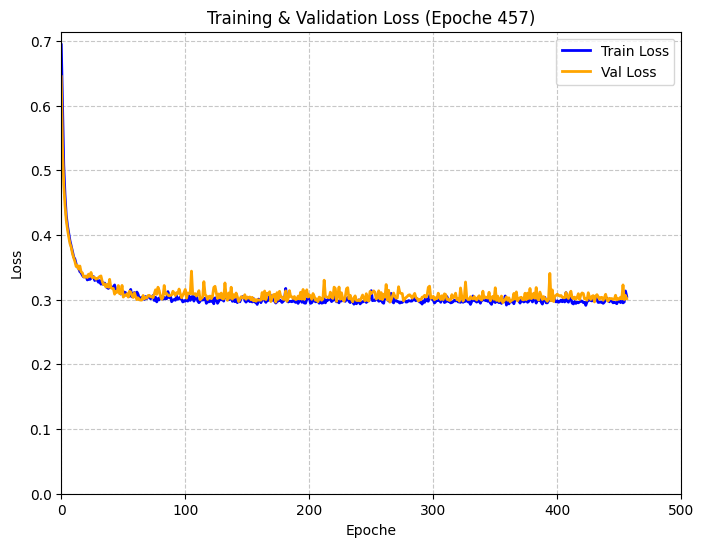


--- Early Stopping ausgeloest in Epoche 457 ---
Bester Validation Loss war: 0.2954

Beste Modellgewichte wurden wiederhergestellt.
Testgenauigkeit:  0.87125
Metadaten gespeichert: Models/metadata_NextStep5.json


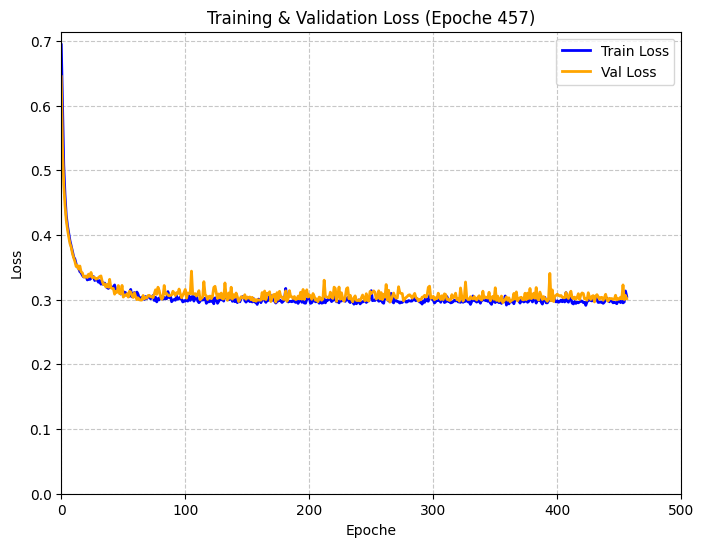

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
import joblib
import json
from torch.utils.data import TensorDataset, DataLoader
import copy
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# --- Reproduzierbarkeit: alle relevanten Zufallsquellen fixieren ---
# Ohne torch.manual_seed waeren Gewichts-Initialisierung und das Shuffeln im
# DataLoader bei jedem Lauf anders -> nicht reproduzierbare Ergebnisse.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 1. Laden des Datensatzes
df = pd.read_csv(DATA_PATH)

# 2. Features (X) und Target (y) trennen
X = df.drop(['A_id','Quality'], axis=1).values # Löschen unnötige Spalten als Liste und Target
y = df['Quality'].values

# Feature-Namen direkt aus den Daten ableiten (verbindliche Reihenfolge fuer die Inferenz!)
feature_names = df.drop('Quality', axis=1).columns.tolist()

# LabelEncoder sortiert die gefundenen Text-Kategorien standardmaessig alphabetisch
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Aufteilen des Datensatzes (Train / Val / Test) - beide Splits mit demselben SEED
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED)

# --- Feature Scaling ---
# Fuer neuronale Netze ist Skalierung essenziell fuer die Konvergenz. Gaengige Methoden:
# 1. StandardScaler (Standardisierung): Mittelwert = 0, Standardabweichung = 1 (Standard fuer NNs)
# 2. MinMaxScaler (Normalisierung): Skaliert Werte starr in einen Bereich (meist 0 bis 1)
# 3. RobustScaler: Nutzt Median und Quartile, sehr robust gegenueber Ausreissern (Outliers)
# Die Auswahl erfolgt zentral ueber SCALER_TYPE in der Konfiguration:
if SCALER_TYPE == 'standard':
    scaler = StandardScaler()
elif SCALER_TYPE == 'minmax':
    scaler = MinMaxScaler()
elif SCALER_TYPE == 'robust':
    scaler = RobustScaler()
else:
    raise ValueError(f"Unbekannter SCALER_TYPE: {SCALER_TYPE!r} (erlaubt: 'standard', 'minmax', 'robust')")

# WICHTIG (Vermeidung von Data Leakage): 'fit_transform' NUR auf Trainingsdaten anwenden!
# Der Scaler lernt hier die Parameter (z.B. Mittelwert/Varianz) der Trainingsdaten.
X_train = scaler.fit_transform(X_train)

# Auf Validierungs- und Testdaten NUR 'transform' anwenden!
# Sie werden mit den aus den Trainingsdaten gelernten Parametern skaliert.
X_val  = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# -----------------------------------------

# 4. Umwandeln der skalierten Daten in PyTorch-Tensoren
X_train = torch.from_numpy(X_train).float()
X_test  = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long()
y_test  = torch.from_numpy(y_test).long()
X_val   = torch.from_numpy(X_val).float()
y_val   = torch.from_numpy(y_val).long()

# Dimensionen aus den Daten ableiten (statt hartkodiert -> keine Inkonsistenzen mehr)
input_dim  = X_train.shape[1]    # Anzahl Eingabe-Merkmale
output_dim = len(le.classes_)    # Anzahl Klassen

# TensorDataset und DataLoader erstellen
train_dataset = TensorDataset(X_train, y_train)
# Generator mit Seed -> reproduzierbares Shuffeln in jeder Epoche
g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)

# Definieren des neuronalen Netzes als Sequential-Modell
net = nn.Sequential(
    nn.Linear(input_dim, HIDDEN_DIM),    # Eingabeschicht (input_dim Merkmale) -> versteckte Schicht (HIDDEN_DIM Neuronen)
    nn.ReLU(),                           # Aktivierungsfunktion: ReLU
    nn.Linear(HIDDEN_DIM, output_dim)    # versteckte Schicht (HIDDEN_DIM Neuronen) -> Ausgabeschicht (output_dim Klassen)
)

# Definieren des Verlustkriteriums und des Optimierers
criterion = nn.CrossEntropyLoss()
#optimizer = optim.AdamW(net.parameters(), lr=LEARNING_RATE)
#optimizer = optim.SGD(net.parameters(), lr=LEARNING_RATE)
#optimizer = optim.RMSprop(net.parameters(), lr=LEARNING_RATE)
optimizer = optim.SGD(net.parameters(), lr=LEARNING_RATE, momentum=0.9)
#optimizer = optim.Adam(net.parameters(), lr=LEARNING_RATE)

# --- Setup fuer Early Stopping ---
patience_counter = 0          # Zaehler fuer die Epochen ohne Verbesserung
best_val_loss = float('inf')  # bester bisher gesehener Validation Loss (als float)
best_model_weights = None     # hier speichern wir die besten Gewichte

# Listen zum Speichern der Historie (ideal fuer spaetere Plots, z.B. mit matplotlib)
history = {'train_loss': [], 'val_loss': []}

# Setup der Figur VOR der Schleife
fig, ax = plt.subplots(figsize=(8, 6))

# Trainieren des neuronalen Netzes
for epoch in range(MAX_EPOCHS):
    net.train()  # Trainingsmodus aktivieren (relevant fuer Dropout/BatchNorm)
    kumulierter_train_loss = 0.0  # Variable zum Aufsummieren des Batch-Losses

    for batch_data in train_loader:  # Schleife ueber die Batches aus dem DataLoader
        batch_X = batch_data[0]
        batch_y = batch_data[1]
        optimizer.zero_grad()
        outputs = net(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        # Loss aufsummieren
        kumulierter_train_loss += loss.item()

    durchschnittlicher_train_loss = kumulierter_train_loss / len(train_loader)
    history['train_loss'].append(durchschnittlicher_train_loss)

    # Validierung nach jeder Epoche
    net.eval()
    with torch.no_grad():
        val_out  = net(X_val)
        val_loss = criterion(val_out, y_val).item()  # direkt als float speichern

    history['val_loss'].append(val_loss)
    print(f'Epoch {epoch:3d} | Loss: {durchschnittlicher_train_loss:.4f} | Val Loss: {val_loss:.4f}')

        # --- Live Plotting in Jupyter ---
    ax.clear() # Löscht die alten Linien im Plot-Objekt
    
    ax.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    ax.plot(history['val_loss'],   label='Val Loss', color='orange', linewidth=2)
    
    ax.set_xlabel('Epoche')
    ax.set_ylabel('Loss')
    ax.set_title(f'Training & Validation Loss (Epoche {epoch+1})')
    ax.set_xlim(0, MAX_EPOCHS) 
    ax.set_ylim(bottom=0) # Lässt Matplotlib das obere Limit automatisch anpassen!
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Der Jupyter-Magic-Trick:
    clear_output(wait=True) # Löscht den alten Output der Zelle (wait=True verhindert Flackern)
    display(fig)            # Zeichnet die aktualisierte Figur
    # --------------------------------
    
    # --- Early Stopping Logik ---
    # Ist der aktuelle Validation Loss der beste, den wir je gesehen haben?
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0  # Zaehler zuruecksetzen
        best_model_weights = copy.deepcopy(net.state_dict())
    else:
        patience_counter += 1  # Keine Verbesserung -> Zaehler erhoehen

    # Zu lange keine Verbesserung -> Abbruch!
    if patience_counter >= PATIENCE:
        print(f"\n--- Early Stopping ausgeloest in Epoche {epoch+1} ---")
        print(f"Bester Validation Loss war: {best_val_loss:.4f}")
        break
    # ----------------------------------------------

# Wir laden die besten Gewichte zurueck in das Modell.
# Ohne diesen Schritt haetten wir das Modell im Zustand des Overfittings!
net.load_state_dict(best_model_weights)
print("\nBeste Modellgewichte wurden wiederhergestellt.")


# Auswerten des neuronalen Netzes auf den Testdaten
net.eval()
with torch.no_grad():
    outputs = net(X_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = accuracy_score(y_test, predicted)
    print('Testgenauigkeit: ', accuracy)

# --- Abspeichern: Modell, Encoder, Scaler + Metadaten ---
torch.save(net.state_dict(), MODEL_PATH)
joblib.dump(le, ENCODER_PATH)
joblib.dump(scaler, SCALER_PATH)

# Metadaten beschreiben, WIE das Modell zu benutzen ist: Feature-Reihenfolge,
# Klassen-Mapping, Skalierungstyp, Architektur und Version. Ohne sie muss
# beim spaeteren Laden alles erraten werden.
metadata = {
    'feature_names': feature_names,
    'class_names': le.classes_.tolist(),
    'class_mapping': {int(i): name for i, name in enumerate(le.classes_)},
    'scaler_type': SCALER_TYPE,
    'architecture': {
        'input_dim': int(input_dim),
        'hidden_dim': int(HIDDEN_DIM),
        'output_dim': int(output_dim),
    },
    'best_val_loss': float(best_val_loss),
    'test_accuracy': float(accuracy),
    'seed': SEED,
    'torch_version': torch.__version__,
}
with open(METADATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print("Metadaten gespeichert:", METADATA_PATH)


In [16]:
# Wiederladen von Modell + Artefakten (aus den Metadaten rekonstruiert)
import torch
import torch.nn as nn
import joblib
import json

# Metadaten ZUERST laden -> daraus die Architektur rekonstruieren
with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)
arch = metadata['architecture']

# WICHTIG: Erst die Architektur definieren, DANN die Gewichte laden.
# (Im urspruenglichen Skript war die Reihenfolge vertauscht: die geladenen
#  Gewichte wurden sofort durch ein neu initialisiertes Netz ueberschrieben.)
net = nn.Sequential(
    nn.Linear(arch['input_dim'], arch['hidden_dim']),    # Eingabeschicht -> versteckte Schicht
    nn.ReLU(),                                           # Aktivierungsfunktion: ReLU
    nn.Linear(arch['hidden_dim'], arch['output_dim'])    # versteckte Schicht -> Ausgabeschicht
)
net.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
net.eval()

le = joblib.load(ENCODER_PATH)
scaler = joblib.load(SCALER_PATH)

for k, v in net.named_parameters():
    print(k, v)


0.weight Parameter containing:
tensor([[-0.2872, -0.4448,  1.6106,  2.7867],
        [-1.1337,  2.8158, -1.2421, -0.3396],
        [ 0.2337, -0.4776,  0.5690,  0.3107],
        [ 0.9419, -0.9335,  1.0892, -1.1039],
        [ 0.5622,  0.9887,  0.5746,  1.1958]], requires_grad=True)
0.bias Parameter containing:
tensor([-1.4992, -0.8156, -0.3707,  1.2590, -1.1999], requires_grad=True)
2.weight Parameter containing:
tensor([[-0.2918,  1.9912, -1.4623, -2.2689, -0.4608],
        [-0.7106, -1.3232,  1.1151,  1.2999, -0.7856],
        [ 1.3534, -1.1498,  1.5966,  0.8476,  0.0469]], requires_grad=True)
2.bias Parameter containing:
tensor([ 0.0912,  0.4181, -1.7056], requires_grad=True)


In [17]:
# Vorhersage mit dem trainierten Netz
# Statt interaktivem input() definieren wir die Eingaben als Array. Das ist
# reproduzierbar, skript-/batch-tauglich und leicht erweiterbar: einfach
# weitere Zeilen ergaenzen. Die Spalten-Reihenfolge MUSS metadata['feature_names'] entsprechen.
import numpy as np

print("Erwartete Merkmal-Reihenfolge:", metadata['feature_names'])

# Beispiel-Eingaben (eine Zeile = ein Datenpunkt)
beispiel_eingaben = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.7, 3.0, 5.2, 2.3],
])

# Skalierung mit demselben (geladenen) Scaler wie im Training
eingabe_skaliert = scaler.transform(beispiel_eingaben)

# Erstellen eines Tensors aus den Eingabewerten
inputs = torch.tensor(eingabe_skaliert, dtype=torch.float32)

# Vorhersage treffen
with torch.no_grad():
    outputs = net(inputs)
    _, predicted = torch.max(outputs, 1)

# Ausgabe der Klassifizierungsaussage je Datenpunkt
for i, idx in enumerate(predicted):
    klasse = le.inverse_transform([idx.item()])[0]
    print(f"Eingabe {beispiel_eingaben[i].tolist()} -> Klasse: {klasse}")


Erwartete Merkmal-Reihenfolge: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Eingabe [5.1, 3.5, 1.4, 0.2] -> Klasse: setosa
Eingabe [6.7, 3.0, 5.2, 2.3] -> Klasse: virginica


In [18]:
# Vorhersagen als Wahrscheinlichkeiten (nutzt 'inputs' aus der vorherigen Zelle)
import torch.nn.functional as F

# Vorhersage des Netzes
with torch.no_grad():
    output = net(inputs)
    _, max_index = torch.max(output, 1)

# Klassenwahrscheinlichkeiten berechnen
probabilities = F.softmax(output, dim=1)

for i in range(len(inputs)):
    klasse = le.inverse_transform([max_index[i].item()])[0]
    wahrscheinlichkeiten = {
        le.classes_[c]: round(float(probabilities[i, c]), 4)
        for c in range(len(le.classes_))
    }
    print(f"Datenpunkt {i}: Klasse = {klasse} | Wahrscheinlichkeiten = {wahrscheinlichkeiten}")


Datenpunkt 0: Klasse = setosa | Wahrscheinlichkeiten = {'setosa': 1.0, 'versicolor': 0.0, 'virginica': 0.0}
Datenpunkt 1: Klasse = virginica | Wahrscheinlichkeiten = {'setosa': 0.0, 'versicolor': 0.0023, 'virginica': 0.9977}
